**Tarea 3, Data Analysis and Machine Learning** \
Juan José Altamirano Paredes \
2022403951

## Librerías y descripción de variables

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import missingno as msn

%matplotlib inline

**Diccionario de variables**
- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

## Carga y limpieza de datos

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [24]:
df = pd.read_csv('junaeb3.csv')

In [25]:
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


<AxesSubplot: >

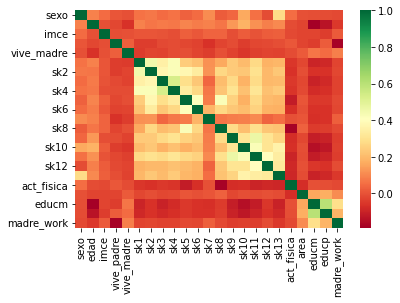

In [5]:
sns.heatmap(df.corr(), cmap='RdYlGn')

## Exploratory Factorial Analysis (EFA)

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [26]:
df1 = df.loc[:, 'sk1':'sk13'] #Seleccionamos las columnas desde sk1 hasta sk13

**INVERTIMOS LA ESCALA**

La idea de invertir la escala fue pensada en conjunto con Joaquín Aravena, con el objetivo de que para las variables "sk_n", 1 represente "nunca" y 5 represente "siempre". De esta manera, las cargas de cada factor en futuras regresiones se entenderá de mejor manera

In [92]:
df1= 6 - df1 #Transformación

In [93]:
df[df1.columns]=df1 #Reemplazo en df original

In [31]:
df.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,4.885912,4.608823,4.737144,4.743648,4.731412,...,4.666334,4.146257,4.614651,4.497215,4.305265,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,...,5.000000,4.000000,4.000000,4.000000,4.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,4.000000,5.000000,5.000000,5.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


Realizamos análisis de factores aplicando la rotación VARIMAX

In [95]:
fa = FactorAnalyzer(rotation='varimax').fit(df1) 

Obtenemos la matriz de cargas factoriales asociadas a 3 factores (Esta cantidad está por defecto en la función de Factor Analyzer)

In [96]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.183970, 0.549198, 0.155598],
       [0.177203, 0.517433, 0.350410],
       [0.182944, 0.596588, 0.168045],
       [0.198779, 0.686060, 0.200987],
       [0.121309, 0.219980, 0.724979],
       [0.173086, 0.210702, 0.481159],
       [0.069524, 0.074626, 0.136478],
       [0.269342, 0.104813, 0.478344],
       [0.495931, 0.215337, 0.207927],
       [0.563365, 0.122575, 0.127228],
       [0.664883, 0.209988, 0.205834],
       [0.526984, 0.116246, 0.144172],
       [0.485171, 0.154101, 0.134872]])

In [34]:
fa.get_eigenvalues()

(array([4.114952, 1.341624, 1.100575, 1.000161, 0.781977, 0.698537,
        0.695787, 0.684453, 0.604042, 0.523209, 0.512081, 0.487796,
        0.454807]),
 array([3.526388, 0.743955, 0.517426, 0.211290, 0.114533, 0.062767,
        0.008348, -0.008400, -0.035529, -0.060437, -0.080399, -0.084919,
        -0.127254]))

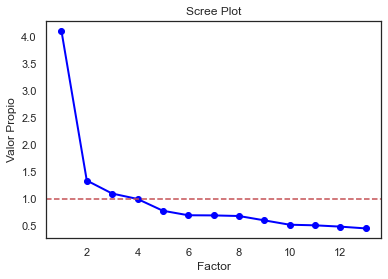

In [35]:
values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.axhline(y=1, color='r', linestyle='--', label='Criterio de Kaiser (autovalor > 1)')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Valor Propio')
plt.show()

Comprobamos mediante el método del codo y el criterio de Kaiser (eigenvalues>1) que la cantidad óptima de factores para el ejercicio es 3.

Para visualizar de mejor manera las cargas de una de las variables sk_n, realizamos un heatmap que interprete estos resultados

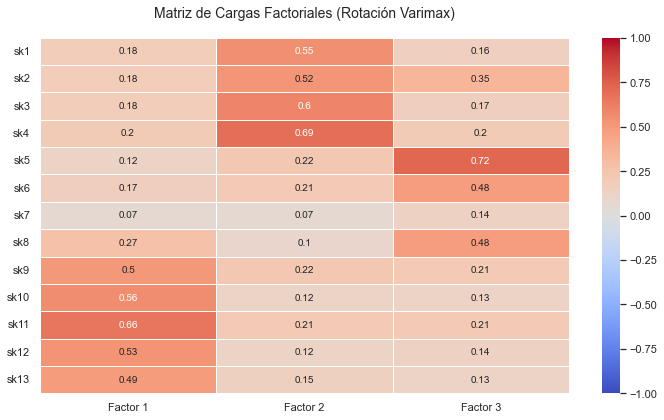

In [ ]:
loadings = fa.loadings_

Crear un DataFrame con nombres
loadings_df = pd.DataFrame(
    loadings,
    index=df1.columns,  # Nombres de las variables (sk1, sk2, ...)
    columns=[f"Factor {i+1}" for i in range(loadings.shape[1])]  # Factor 1, Factor 2, ...
)
sns.set(style="white")
plt.figure(figsize=(10, 6))

# Heatmap de matriz de Cargas Factoriales
heatmap = sns.heatmap(
    loadings_df.round(2),
    annot=True,  # Muestra los valores
    cmap="coolwarm", 
    center=0,
    vmin=-1, 
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 10}
)

# Ajustes adicionales
plt.title("Matriz de Cargas Factoriales (Rotación Varimax)", pad=20, fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

 El **Factor 1** muestra cargas altas en las variables **sk9** (hace preguntas a adultos), **sk10** (interés por libros), **sk11** (interés por el entorno), **sk12** (juega a armar/desarmar) y **sk13** (expresiones artísticas). Estas variables se podrían agrupar bajo el nombre de "Curiosidad y Habilidades Cognitivas".
 
 El **Factor 2** destaca en **sk1** (afecto a padres), **sk2** (afecto a pares), **sk3** (expresa sentimientos) y **sk4** (usa gestos para sentimientos), por lo tanto se puede titular "Habilidades Socioafectivas y Emocionales".
 
 Por último, el **Factor 3** tiene cargas significativas en **sk5** (juega con otros), **sk6** (comparte) y **sk8** (participa en juegos grupales), asociándose a "Conducta de Cooperación". 
 
 La variable **sk7** (agresividad) no carga significativamente en ningún factor, lo que podría indicar que no se integra en estas dimensiones.

In [37]:
fa.get_factor_variance()

(array([1.778781, 1.648043, 1.360946]),
 array([0.136829, 0.126773, 0.104688]),
 array([0.136829, 0.263602, 0.368290]))

Notamos como estos 3 factores explican un 36.8% de la variabilidad total de los datos.

## Pregunta 3

3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [ ]:
# Obtenemos scores factoriales 
factor_scores = fa.transform(df1)  # df1 contiene las variables sk1 a sk13

# Creamos un df con los scores y las variables de interés
df_scores = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])

# Añadimos las variables de interés al df
df_scores['sexo'] = df['sexo'] 
df_scores['area'] = df['area']  
df_scores['imce'] = df['imce'] 
df_scores['act_fisica'] = df['act_fisica'] 

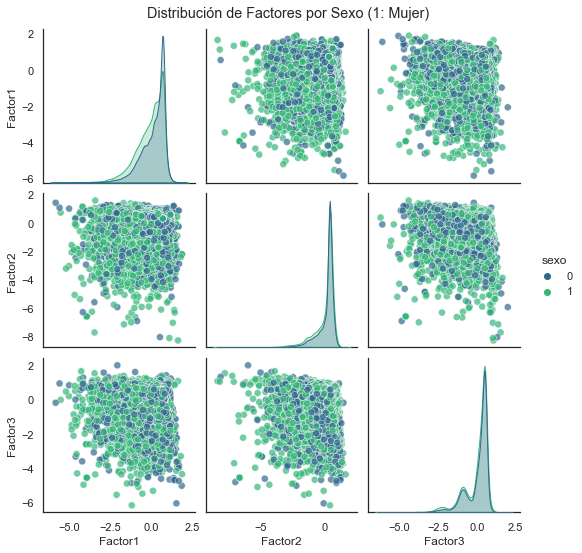

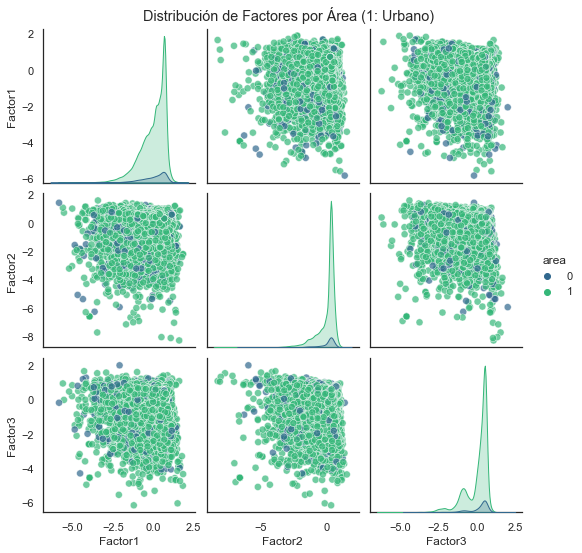

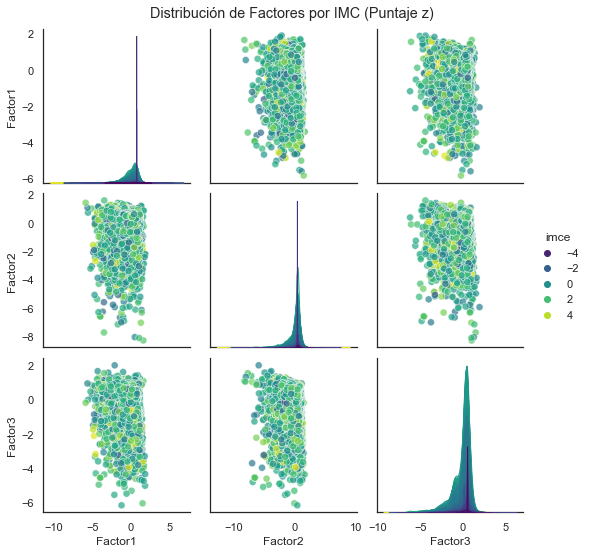

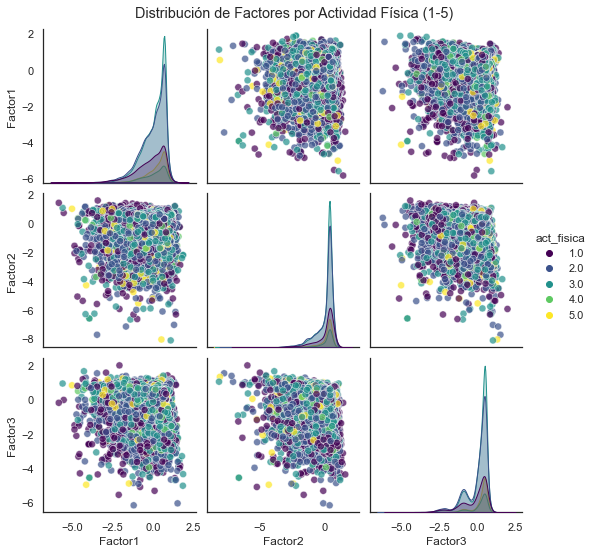

In [ ]:
# Creamos una función para graficar.
def plot1(hue_var, title):
    g = sns.pairplot(
        df_scores,
        vars=['Factor1', 'Factor2', 'Factor3'],
        hue=hue_var,
        palette='viridis',
        plot_kws={'alpha': 0.7, 's': 50},
        diag_kind='kde'
    )
    g.fig.suptitle(title, y=1.02)
    plt.show()

# Graficamos para cada variable de interés
plot1('sexo', 'Distribución de Factores por Sexo (1: Mujer)')
plot1('area', 'Distribución de Factores por Área (1: Urbano)')
plot1('imce', 'Distribución de Factores por IMC (Puntaje z)')
plot1('act_fisica', 'Distribución de Factores por Actividad Física (1-5)')

Podemos notar que al realizar un cruce entre factores y analizar el comportamiento de las variables de caracterización se encuentra gran superposición, por lo tanto no existen mayores diferencias entre distintos valores, más allá de la cantidad asociada a cada uno de los valores de las variables.

## Confirmatory Factorial Analysis (CFA)

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

Procedemos a definir cada factor con el nombre representativo que obtuvimos en la pregunta 2 y asignando las cargas resultantes en el EFA para comprobar dicho análisis.

In [103]:
mod =  """
    # Definición de factores
    Habilidades_Socioafectivas =~ sk1 + sk2 + sk3 + sk4
    Habilidades_Cognitivas =~ sk9 + sk10 + sk11 + sk12 + sk13
    Conducta_Cooperacion =~ sk5 + sk6 + sk8

"""

model = semopy.Model(mod)
out=model.fit(df1)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.142
Number of iterations: 42
Params: 1.793 1.603 1.778 1.335 1.233 1.092 1.261 1.027 1.155 0.165 0.096 0.160 0.055 0.063 0.057 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.284


In [104]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk1,~,Habilidades_Socioafectivas,1.000000,0.595909,-,-,-
1,sk2,~,Habilidades_Socioafectivas,1.793157,0.647690,0.021586,83.072223,0.0
2,sk3,~,Habilidades_Socioafectivas,1.603422,0.642710,0.019395,82.673817,0.0
3,sk4,~,Habilidades_Socioafectivas,1.777960,0.721890,0.020174,88.132298,0.0
4,sk9,~,Habilidades_Cognitivas,1.000000,0.600501,-,-,-
5,sk10,~,Habilidades_Cognitivas,1.334713,0.567130,0.017645,75.641962,0.0
6,sk11,~,Habilidades_Cognitivas,1.232807,0.737146,0.013993,88.102986,0.0
7,sk12,~,Habilidades_Cognitivas,1.091950,0.546278,0.014832,73.622089,0.0
8,sk13,~,Habilidades_Cognitivas,1.261417,0.512138,0.017981,70.151539,0.0
9,sk5,~,Conducta_Cooperacion,1.000000,0.719657,-,-,-


El CFA confirmó la significancia de todas las variables integradas para cada factor. (p_value< 0.05). 
Notamos para cada factor una carga considerable de cada una de las variables que lo componen, superior al valor de referencia. (Estimate)



In [43]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4401.365973,0.0,87611.052484,0.950307,0.949762,0.934987,0.949762,0.935692,0.052411,53.716544,278.991452,0.141728


Por último, los valores de CFI>0.9 ; TLI >0.93 ; RMSEA<0.6 reflejan la significancia de nuestro modelo.

## Latent Class

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.09s/it, max_LL=-5.42e+4, max_avg_LL=-1.75]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.97s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:30<00:00, 30.81s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]
c:\Users\juanj\AppData\Local\Programs\Python\Python310\lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:34<00:00, 34.85s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]
c:\Users\juanj\AppData\Local\Programs\Python\Python310\lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


<AxesSubplot: >

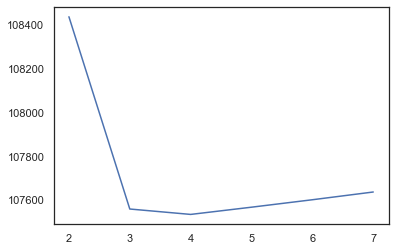

In [ ]:
from stepmix.stepmix import StepMix
df2=df[['imce']] #Utilizamos solo la columna de imce




# Numero optimo de clusters
K = range(2, 8)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df2)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df2))

sns.lineplot(x = K, y = BIC)   

Notamos que con el método del codo, existe un descenso marginal en n=3, y posteriormente un extraño ascenso del BIC a mayores n. Por lo tanto se utilizarán 3 clusters.

In [45]:
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(df2)
df2['pred']=model.predict(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.99s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            2.4074  0.5922 -1.9669
    Class weights
        Class 1 : 0.27
        Class 2 : 0.71
        Class 3 : 0.02
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 31055
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -53735.8888
    -2LL                          : 107471.7775
    Average LL                    : -1.7303
    AIC                           : 107481.78
    BIC                           : 107523.50
    CAIC                          : 107528.50
    Sample-Size Adjusted BIC      : 107559.32
    Entropy                       : 11958.6120
    Scaled Relative Entropy       : 0.6495



C:\Users\juanj\AppData\Local\Temp\ipykernel_29596\2136898485.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['pred']=model.predict(df2)


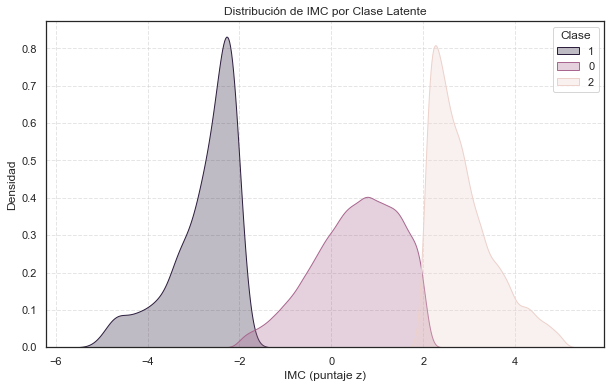

In [46]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df2,
    x='imce',
    hue='pred',  # Columna con las clases latentes
    #palette='viridis',  # Paleta de colores
    fill=True,       # Rellenar las áreas bajo la curva
    alpha=0.3,       # Transparencia para ver superposiciones
    common_norm=False  # Normalizar cada distribución por separado
)
# sns.kdeplot(
#     data=df2,
#     x='imce',
#     #hue='pred',  # Columna con las clases latentes
#     #palette='viridis',  # Paleta de colores
#     fill=True,       # Rellenar las áreas bajo la curva
#     alpha=0.3,       # Transparencia para ver superposiciones
#     #common_norm=False  # Normalizar cada distribución por separado
# )

plt.title('Distribución de IMC por Clase Latente')
plt.xlabel('IMC (puntaje z)')
plt.ylabel('Densidad')
plt.legend(title='Clase', labels=df2['pred'].unique())
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

El gráfico presentado, muestra la distribución de cada uno de los clusters resultantes. Los datos se estandarizaron en términos de densidad para un mejor entendimiento de su distribución, ya que como pudimos ver en los pesos de cada clase, la clase 2 concentra tan solo un 2% de los datos.

Podemos ver que existe una clara clasificación en 3 grupos, los cuales podríamos denominar de la siguiente manera:

**Clase 0:** "IMC Saludable" |
**Clase 1:** "IMC Bajo peso" |
**Clase 2:** "IMC Sobre peso" |

## SEM Completo

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

En primer lugar, modificaremos algunas categóricas para ingresarlas como categóricas al modelo:

In [47]:
# Creamos variables dummies para ver si vive con madre
df['madre_presente'] = df['vive_madre'].apply(lambda x: 1 if x >= 1 else 0)  # 1 para vive_madre=1 o 2
df['madre_multiple'] = (df['vive_madre'] == 2).astype(int)  # 1 solo para vive_madre=2


In [ ]:
# Creamos variables dummies para ver si vive con padre
df['padre_presente'] = df['vive_padre'].apply(lambda x: 1 if x >= 1 else 0)  # 1 para vive_padre=1 o 2
#df['padre_multiple'] = (df['vive_padre'] == 2).astype(int)  # 1 solo para vive_padre=2

Creamos una variable de "padres presentes" en caso de que viva al menos con una madre y un padre

In [49]:
df['padres_presentes'] = df['vive_padre']+df['vive_madre']
df['padres_presentes'] = df['padres_presentes'].apply(lambda x: 1 if x == 2 else 0)

In [50]:
df['madre_empleada'] = (df['madre_work'] == 1).astype(int)
df['madre_labor_domestica'] = (df['madre_work'] == -1).astype(int)

Para construir el modelo se consideraron las siguientes hipótesis:

1. Cuando los niños tienen padres presentes tienden a desarrollar más sus emociones, por lo cual vivir con su padre y/ o madre, puede contribuir a mejorar sus habilidades socioafectivas.
2. Los niveles de educación de los padres de un niño o niña pueden contribuir a aportar significativamente en sus habilidades cognitivas, puesto que los padres transmitirían conocimiento a sus hijes. Además, la edad del niño o niña también puede contribuir al desarrollo de sus hablilidades cognitivas.
3. Hacer actividad física en la niñez desarrolla el comportamiento de los individuos en entornos de coolaboración, trabajo en equipo y relaciones sociales. Además, las habilidades cognitivas de las y los niños pueden afectar directamente en su comportamiento con el resto de niños y niñas, pues si tienen más conocimientos pueden estar dispuestos a compartirlos.

4. Intuitivamente, el nivel de actividad física realizado por un niño puede afectar considerablemente a su IMC. Por otro lado, si un niño o niña cuenta con una madre que realice labores domésticas, tendrá un cuidado continuo, lo cual permite una mejor supervisión de su alimentación, acercándolo a un IMC más sano. Además, el nivel educacional de la madre puede contribuir a una variación en el IMC, puesto que una madre más instruida puede implicar mejores hábitos alimenticios en el hogar. Por último, el entorno en el que viven los individuos (rural o urbano) puede limitarlo de comer ciertos alimentos que influyen en un IMC poco sano, por lo cual podría tener alguna influencia en el IMC.

In [102]:
# Definimos el modelo SEM:
model_sem = """
    # Measurment
    Habilidades_Socioafectivas =~ sk1 + sk2 + sk3 + sk4
    Habilidades_Cognitivas =~ sk9 + sk10 + sk11 + sk12 + sk13
    Conducta_Cooperacion =~ sk5 + sk6 + sk8

    # Regresion Estructural
    imce ~ Habilidades_Socioafectivas + Habilidades_Cognitivas + Conducta_Cooperacion + act_fisica  + madre_labor_domestica + educm + area
    Habilidades_Socioafectivas ~ vive_padre + vive_madre 
    Habilidades_Cognitivas ~ educp + educm + edad
    Conducta_Cooperacion ~ act_fisica + Habilidades_Cognitivas
    
"""
# Ajustamos el modelo
data = df.drop(columns='sk7')
mod = semopy.Model(model_sem)
result = mod.fit(data)
print(result)
#####################
print(semopy.calc_stats(mod))
##################
mod.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.548
Number of iterations: 47
Params: 1.682 1.634 1.816 1.378 1.230 1.103 1.268 1.030 1.288 -0.161 -0.045 0.194 -0.018 -0.076 -0.013 -0.134 -0.019 -0.051 -0.008 -0.011 0.016 -0.049 0.579 0.095 0.148 0.055 1.869 0.100 0.586 0.209 0.447 0.717 0.266 0.195 0.151 0.166 0.388 0.443 0.286
       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  192           218  17030.9655           0.0  111770.860707  0.849049   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.847626  0.826992  0.847626  0.828608  0.053143  76.903174   

              BIC    LogLik  
Value  402.300263  0.548413  


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,Habilidades_Socioafectivas,~,vive_padre,-0.019237,-0.036667,0.003421,-5.622825,0.0
1,Habilidades_Socioafectivas,~,vive_madre,-0.050601,-0.040704,0.008109,-6.240275,0.0
2,Habilidades_Cognitivas,~,educp,-0.008368,-0.072191,0.000917,-9.125856,0.0
3,Habilidades_Cognitivas,~,educm,-0.011428,-0.096094,0.00095,-12.028627,0.0
4,Habilidades_Cognitivas,~,edad,0.015899,0.174612,0.000601,26.436689,0.0
5,Conducta_Cooperacion,~,act_fisica,-0.048521,-0.133415,0.002327,-20.854067,0.0
6,Conducta_Cooperacion,~,Habilidades_Cognitivas,0.579033,0.591829,0.009544,60.67018,0.0
7,sk1,~,Habilidades_Socioafectivas,1.000000,0.598606,-,-,-
8,sk2,~,Habilidades_Socioafectivas,1.682070,0.609875,0.021843,77.005648,0.0
9,sk3,~,Habilidades_Socioafectivas,1.634197,0.657745,0.020328,80.392774,0.0


Podemos concluir que gran parte de las hipótesis expuestas se confirman estadísticamente, puesto que las variables mencionadas son significativas en los modelos estructurales propuestos. Lo que interesa fundamentalmente es la magnitud y la relación que existe entre las variables explicativas y la veariable independiente:

Notamos como efectivamente todas las variables incorporadas a la explicación del IMCE se relacionan inversamente con él, a excepción del factor "Conducta_Cooperación", que muestra una relación positiva, aunque relativamente baja. Se destaca que el Factor "Habilidades COgnitivas" no es significativo para una variación del IMCE.

Por otro lado, notamos como las variables expuestas para los modelos estructurales de los 3 factores son significativas, lo que permite confirmar estadísticamente la significancia de las hipótesis 1,2 y 3. Lo que sorprende son las relaciones negativas entre Habilidades cognitivas y los años de educación de los padres, ya que el aumento de estas variables disminuyen el valor del factor. 

Se puede ver que existe una relación positiva entre el factor habilidades cognitivas y conducta de cooperación, tal como se preveía en la hipótesis 3. 

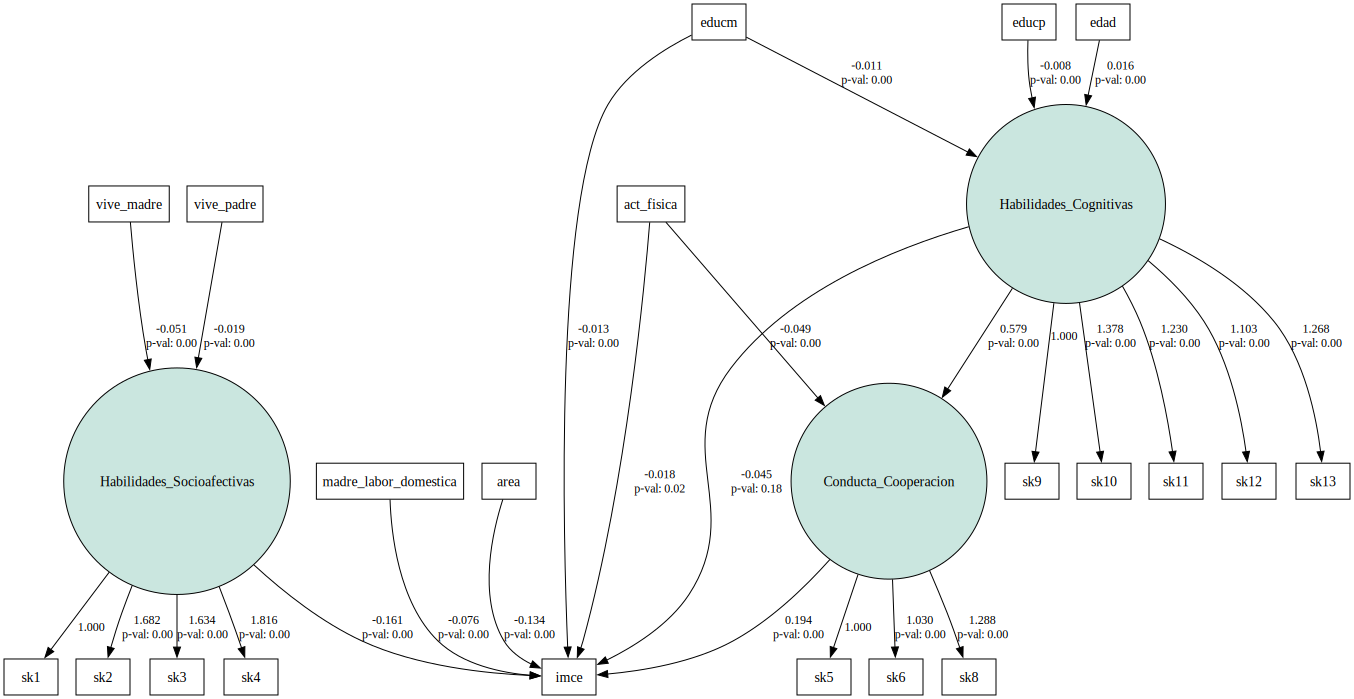

In [100]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

from graphviz import Digraph

semopy.semplot(mod, "semmodel.png")

## Análisis CFA por Clases

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

In [98]:
df['class']=df2['pred'] #Incorporamos la clasificación obtenida en el análisis de clases latentes al df original.

In [99]:
# Creamos las submuestras de cada uno de los clusters
df_sano=df[df['class']==0]
df_sobrepeso = df[df['class']==2]
df_bajopeso = df[df['class']==1]


### CFA para Clase "IMC Sano"

In [89]:
mod = semopy.Model(model_sem)
result = mod.fit(df_sano)
print(result)
#####################
print(semopy.calc_stats(mod))
##################
mod.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.579
Number of iterations: 43
Params: 1.591 1.434 1.568 1.391 1.227 1.146 1.338 0.986 1.247 0.063 0.033 -0.133 0.003 0.012 -0.011 0.007 0.027 0.030 0.005 0.013 -0.016 0.057 0.613 0.110 0.155 0.069 0.453 0.096 0.615 0.219 0.467 0.739 0.266 0.213 0.158 0.184 0.406 0.481 0.278
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  192           218  4084.685919           0.0   25938.924592  0.848657   

            GFI      AGFI       NFI       TLI     RMSEA        AIC        BIC  \
Value  0.842527  0.821202  0.842527  0.828162  0.053634  76.841059  344.40606   

        LogLik  
Value  0.57947  


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,Habilidades_Socioafectivas,~,vive_padre,0.027120,0.046759,0.007951,3.41074,0.000648
1,Habilidades_Socioafectivas,~,vive_madre,0.030163,0.022266,0.01855,1.625971,0.103956
2,Habilidades_Cognitivas,~,educp,0.004975,0.041938,0.001909,2.605487,0.009174
3,Habilidades_Cognitivas,~,educm,0.012708,0.104614,0.001985,6.402022,0.0
4,Habilidades_Cognitivas,~,edad,-0.016185,-0.179735,0.001249,-12.952983,0.0
5,Conducta_Cooperacion,~,act_fisica,0.057428,0.141455,0.005408,10.618611,0.0
6,Conducta_Cooperacion,~,Habilidades_Cognitivas,0.612587,0.592964,0.02066,29.650436,0.0
7,sk1,~,Habilidades_Socioafectivas,1.000000,0.646681,-,-,-
8,sk2,~,Habilidades_Socioafectivas,1.591341,0.629282,0.040643,39.153674,0.0
9,sk3,~,Habilidades_Socioafectivas,1.433781,0.631451,0.036541,39.23802,0.0


Podemos destacar que una serie de variables perdieron significancia sobre el modelo estructural diseñado para el IMCE.
Esto se puede deber a que los valores de IMC en este cluster están altamente concentrados en un rango definido, por lo que gran parte de los individuos pueden tener valores similares en distintas variables, generando diferencias no significativas al variar elementos como: Actividad física, Área, Habilidades socioafectivas y habilidades cognitivas.

Se destaca la significancia de variables como el nivel de educación de la madre y el factor "Conducta_Cooperacion" para el IMCE.

### Análisis CFA para Clase "IMC Sobrepeso"

In [90]:
mod = semopy.Model(model_sem)
result = mod.fit(df_sobrepeso)
print(result)
#####################
print(semopy.calc_stats(mod))
##################
mod.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.160
Number of iterations: 43
Params: 2.306 2.005 2.541 1.101 1.157 0.849 1.130 1.109 1.541 -0.562 0.001 0.223 0.104 -0.003 0.029 0.076 0.057 0.026 -0.003 0.027 -0.004 0.058 0.387 0.102 0.198 0.032 0.464 0.073 0.675 0.219 0.375 0.781 0.243 0.201 0.154 0.182 0.451 0.484 0.293
       DoF  DoF Baseline       chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  192           218  478.99474           0.0    1728.366725  0.809983   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.722863  0.685334  0.722863  0.784252  0.060233  75.680413   

              BIC    LogLik  
Value  232.594869  1.159794  


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,Habilidades_Socioafectivas,~,vive_padre,0.056764,0.139023,0.023335,2.432581,0.014992
1,Habilidades_Socioafectivas,~,vive_madre,0.025662,0.023812,0.060353,0.4252,0.670691
2,Habilidades_Cognitivas,~,educp,-0.003208,-0.023475,0.009464,-0.339027,0.734589
3,Habilidades_Cognitivas,~,educm,0.026835,0.190709,0.009925,2.703726,0.006857
4,Habilidades_Cognitivas,~,edad,-0.003780,-0.038779,0.005628,-0.671629,0.50182
5,Conducta_Cooperacion,~,act_fisica,0.058470,0.165678,0.020654,2.830942,0.004641
6,Conducta_Cooperacion,~,Habilidades_Cognitivas,0.386978,0.474999,0.065627,5.896649,0.0
7,sk1,~,Habilidades_Socioafectivas,1.000000,0.556283,-,-,-
8,sk2,~,Habilidades_Socioafectivas,2.305699,0.646254,0.262488,8.784004,0.0
9,sk3,~,Habilidades_Socioafectivas,2.004727,0.629461,0.231386,8.663978,0.0


En este caso, notamos como la variable actividad física logró afectar significativamente al IMC a pesar de encontrarnos en un cluster específico de personas con un IMC sano. Además, el nivel de educación de la madre sigue influyendo en el IMC, lo que eventualmene lo catalogaría como una variable robusta para este análisis diferenciado.
Esta vez se muestra como el factor de Habilidades Socioafectivas también es significativo para el IMC, lo que deja entrever que entre personas con un IMC en rangos sanos, el desarrollar habilidades socioafectivas como demostrar sus sentimientos influyen de manera negativa en el valor de su IMC.

### Análisis CFA para Clase "IMC bajo peso"

In [91]:
mod = semopy.Model(model_sem)
result = mod.fit(df_bajopeso)
print(result)
#####################
print(semopy.calc_stats(mod))
##################
mod.inspect(mode='list', what="names", std_est=True)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.547
Number of iterations: 44
Params: 1.699 1.692 1.886 1.379 1.235 1.094 1.247 1.045 1.295 0.036 0.032 -0.017 -0.004 -0.033 -0.004 -0.062 0.016 0.057 0.010 0.011 -0.016 0.045 0.571 0.091 0.145 0.052 0.824 0.101 0.576 0.205 0.442 0.708 0.266 0.189 0.149 0.160 0.381 0.431 0.288
       DoF  DoF Baseline          chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  192           218  12906.909458           0.0   84609.768299  0.849335   

            GFI      AGFI       NFI       TLI     RMSEA       AIC         BIC  \
Value  0.847454  0.826796  0.847454  0.828932  0.052981  76.90587  391.585378   

         LogLik  
Value  0.547065  


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,Habilidades_Socioafectivas,~,vive_padre,0.016294,0.031870,0.00382,4.265009,0.00002
1,Habilidades_Socioafectivas,~,vive_madre,0.057255,0.047134,0.009087,6.300527,0.0
2,Habilidades_Cognitivas,~,educp,0.009530,0.083042,0.001051,9.064277,0.0
3,Habilidades_Cognitivas,~,educm,0.010728,0.091093,0.001087,9.86689,0.0
4,Habilidades_Cognitivas,~,edad,-0.015992,-0.175316,0.000691,-23.138626,0.0
5,Conducta_Cooperacion,~,act_fisica,0.045421,0.129306,0.002584,17.577877,0.0
6,Conducta_Cooperacion,~,Habilidades_Cognitivas,0.571380,0.593050,0.010879,52.520725,0.0
7,sk1,~,Habilidades_Socioafectivas,1.000000,0.585793,-,-,-
8,sk2,~,Habilidades_Socioafectivas,1.699203,0.603171,0.025807,65.84147,0.0
9,sk3,~,Habilidades_Socioafectivas,1.691770,0.665656,0.024327,69.542934,0.0


En este caso, gran parte de las variables del modelo resultaron significativas, a excepción del modelo estructural del IMC, en donde solo son significativas el área de residencia, los años de educación de la madre y la variable binaria que indica si la madre realiza o no labores domésticas. Por lo tanto, para personas con muy bajo IMC, estas son las variables que más influyen en su IMC, todas de manera negativa.
Sin embargo, es importante mencionar que la carga de esta clase, es decir, la cantidad de individuos que pertenecen a este cluster es muy baja. (2% del total de datos), las conclusiones de este análisis puede ser poco significativo.

##

En conclusión, el realizar el análisis por separado permitió dar cuenta de la robustez de ciertas variables como el nivel educacional de la madre para el IMC en distintos casos. Como era de esperar, gran parte de las variables que "explicaban" el IMC en el modelo original, dejaron de ser significativas, puesto que los datos al clasificarlos y analizarlos por separados son más homogéneos, disminuyendo ciertas variabilidades que se puedan explicar con estos análisis.